In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Loss

   step       loss
0     0  10.971584
1     1  10.763372
2     2  10.558155
3     3  10.312304
4     4  10.110755
   step       loss
0     0  10.761782
1  1000   3.027539
2  2000   2.627491
3  3000   2.449507
4  4000   2.347340


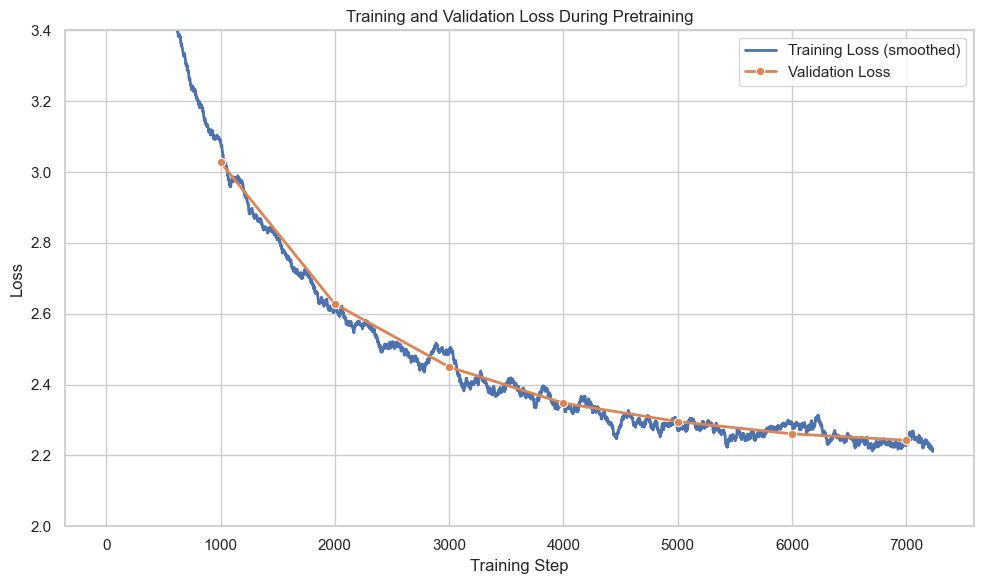

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_loss_path = "losses/train_losses.csv"
val_loss_path = "losses/val_losses.csv"

train_df = pd.read_csv(train_loss_path)
val_df = pd.read_csv(val_loss_path)

# Eğer kolon isimleri farklıysa burayı kontrol et
print(train_df.head())
print(val_df.head())

# Smooth training loss
train_df["smoothed_loss"] = train_df["loss"].rolling(window=100, min_periods=1).mean()

# İlk validation loss çok büyükse grafiği bozuyor, onu ayrı tutuyoruz
val_df_plot = val_df[val_df["step"] > 0]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=train_df,
    x="step",
    y="smoothed_loss",
    label="Training Loss (smoothed)",
    linewidth=2
)

sns.lineplot(
    data=val_df_plot,
    x="step",
    y="loss",
    label="Validation Loss",
    marker="o",
    linewidth=2
)

plt.title("Training and Validation Loss During Pretraining")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.ylim(2.0, 3.4)
plt.legend()
plt.tight_layout()
plt.show()

# Vectorel Analysis

In [4]:
import torch
from model import Config, DecoderModel
device = "mps" if torch.backends.mps.is_available() else "cpu"

random_ckpt_path = "checkpoints/random_decoder.pt"
pretrained_ckpt_path = "checkpoints/pretrained_decoder.pt"

In [5]:
pretrained_checkpoint = torch.load(pretrained_ckpt_path, map_location=device, weights_only=False)
pretrained_config = pretrained_checkpoint["config"]
if isinstance(pretrained_config, dict):
    pretrained_config = Config(**pretrained_config)
pretrained_model = DecoderModel(pretrained_config, device=device)
pretrained_model.load_state_dict(pretrained_checkpoint["model_state_dict"])
pretrained_model.eval()

DecoderModel(
  (embedding): Embedding(50257, 256)
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attention): Attention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (wo): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (up_proj): Linear(in_features=256, out_features=1024, bias=True)
        (down_proj): Linear(in_features=1024, out_features=256, bias=True)
        (act_fn): SiLU()
      )
      (norm_1): RMSNorm((256,), eps=None, elementwise_affine=True)
      (norm_2): RMSNorm((256,), eps=None, elementwise_affine=True)
    )
  )
  (norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=50257, bias=True)
)

In [6]:
random_checkpoint = torch.load(random_ckpt_path, map_location=device, weights_only=False)
random_config = random_checkpoint["config"]
if isinstance(random_config, dict):
    random_config = Config(**random_config)
random_model = DecoderModel(random_config, device=device)
random_model.load_state_dict(random_checkpoint["model_state_dict"])
random_model.eval()

DecoderModel(
  (embedding): Embedding(50257, 256)
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attention): Attention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (wo): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (up_proj): Linear(in_features=256, out_features=1024, bias=True)
        (down_proj): Linear(in_features=1024, out_features=256, bias=True)
        (act_fn): SiLU()
      )
      (norm_1): RMSNorm((256,), eps=None, elementwise_affine=True)
      (norm_2): RMSNorm((256,), eps=None, elementwise_affine=True)
    )
  )
  (norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=50257, bias=True)
)

In [7]:
x = torch.randint(
    low=0,
    high=pretrained_config.vocab_size,
    size=(1, pretrained_config.block_size),
    dtype=torch.long
).to(device)

with torch.no_grad():
    logits = pretrained_model(x)

print(logits.shape)

torch.Size([1, 128, 50257])


## Embeddings Shift

In [8]:
random_emb = random_model.embedding.weight.detach().cpu()
pretrained_emb = pretrained_model.embedding.weight.detach().cpu()

print(random_emb.shape)
print(pretrained_emb.shape)

torch.Size([50257, 256])
torch.Size([50257, 256])


In [9]:
embedding_shift = torch.norm(
    pretrained_emb - random_emb,
    dim=1
)

print("Mean shift:", embedding_shift.mean().item())
print("Std shift:", embedding_shift.std().item())
print("Min shift:", embedding_shift.min().item())
print("Max shift:", embedding_shift.max().item())

Mean shift: 1.9741729497909546
Std shift: 0.3958359956741333
Min shift: 1.443566918373108
Max shift: 4.640376091003418


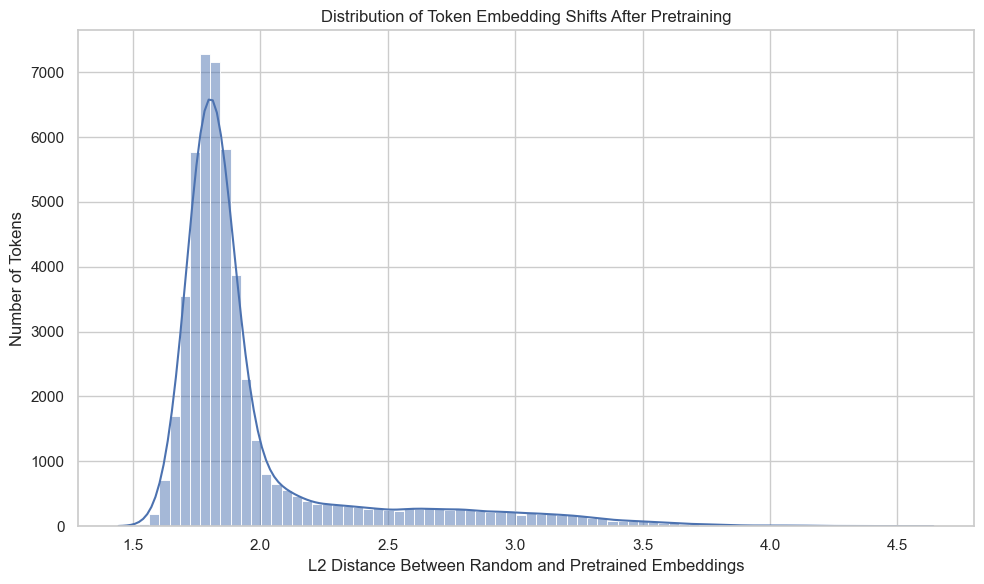

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(
    embedding_shift.numpy(),
    bins=80,
    kde=True
)

plt.title("Distribution of Token Embedding Shifts After Pretraining")
plt.xlabel("L2 Distance Between Random and Pretrained Embeddings")
plt.ylabel("Number of Tokens")

plt.tight_layout()
plt.show()

## PCA

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from transformers import AutoTokenizer

/Users/can/miniconda3/envs/pretrain/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [13]:
sentences = [
    # Royalty
    "The king ruled the kingdom from the palace.",
    "The queen wore a golden crown.",
    "The prince walked through the royal castle.",
    "The princess lived with the royal family.",

    # Animals
    "The dog ran across the park.",
    "The cat slept inside the warm house.",
    "The wolf moved silently through the forest.",
    "The fox walked near the river.",

    # Technology
    "The model learned patterns from data.",
    "The computer processed information quickly.",
    "The algorithm predicted the next result.",
    "The transformer processed a sequence of tokens.",

    # Cities
    "Paris has many streets and museums.",
    "Rome contains ancient buildings and history.",
    "Berlin is a large modern European city.",
    "Madrid is a lively city in Spain."
]

names = [
    "king", "queen", "prince", "princess",
    "dog", "cat", "wolf", "fox",
    "model", "computer", "algorithm", "transformer",
    "paris", "rome", "berlin", "madrid"
]

groups = (
    ["royalty"] * 4 +
    ["animals"] * 4 +
    ["technology"] * 4 +
    ["cities"] * 4
)

In [14]:
def extract_layer_hidden_states(model, input_ids, layer_idx=-1):
    captured = {}

    def hook_fn(module, inputs, output):
        captured["hidden"] = output.detach()

    handle = model.layers[layer_idx].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(input_ids)

    handle.remove()

    return captured["hidden"]

In [15]:
def get_sentence_vectors(model, sentences, tokenizer, device, layer_idx=-1):
    vectors = []

    model.eval()

    for sentence in sentences:
        encoded = tokenizer(
            sentence,
            return_tensors="pt",
            truncation=True,
            max_length=pretrained_config.block_size,
            padding="max_length"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        hidden = extract_layer_hidden_states(
            model=model,
            input_ids=input_ids,
            layer_idx=layer_idx
        )

        mask = attention_mask.unsqueeze(-1)

        hidden = hidden * mask

        sentence_vector = hidden.sum(dim=1) / mask.sum(dim=1)

        vectors.append(sentence_vector.squeeze(0).cpu().numpy())

    return np.array(vectors)

In [16]:
layer_idx = -1  # son layer

random_vectors = get_sentence_vectors(
    model=random_model,
    sentences=sentences,
    tokenizer=tokenizer,
    device=device,
    layer_idx=layer_idx
)

pretrained_vectors = get_sentence_vectors(
    model=pretrained_model,
    sentences=sentences,
    tokenizer=tokenizer,
    device=device,
    layer_idx=layer_idx
)

print("Random vectors:", random_vectors.shape)
print("Pretrained vectors:", pretrained_vectors.shape)

Random vectors: (16, 256)
Pretrained vectors: (16, 256)


In [17]:
all_vectors = np.concatenate(
    [random_vectors, pretrained_vectors],
    axis=0
)

pca = PCA(n_components=2)
all_points = pca.fit_transform(all_vectors)

random_points = all_points[:len(sentences)]
pretrained_points = all_points[len(sentences):]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.27123982 0.1103273 ]


In [18]:
def plot_pca(points, groups, names, title, save_path=None):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=points[:, 0],
        y=points[:, 1],
        hue=groups,
        s=100
    )

    for i, name in enumerate(names):
        plt.annotate(
            name,
            (points[i, 0], points[i, 1]),
            fontsize=9,
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(title="Group")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

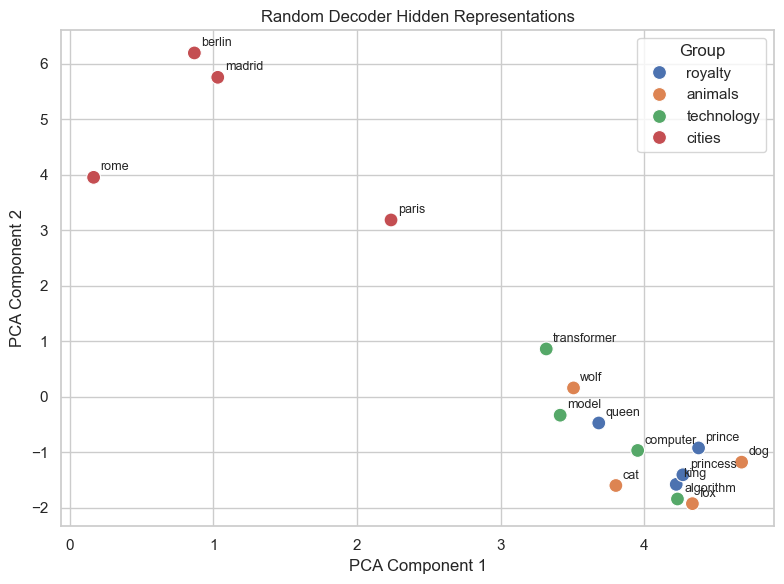

In [21]:
plot_pca(
    points=random_points,
    groups=groups,
    names=names,
    title="Random Decoder Hidden Representations",
    save_path="../assets/random_hidden_pca.png"
)

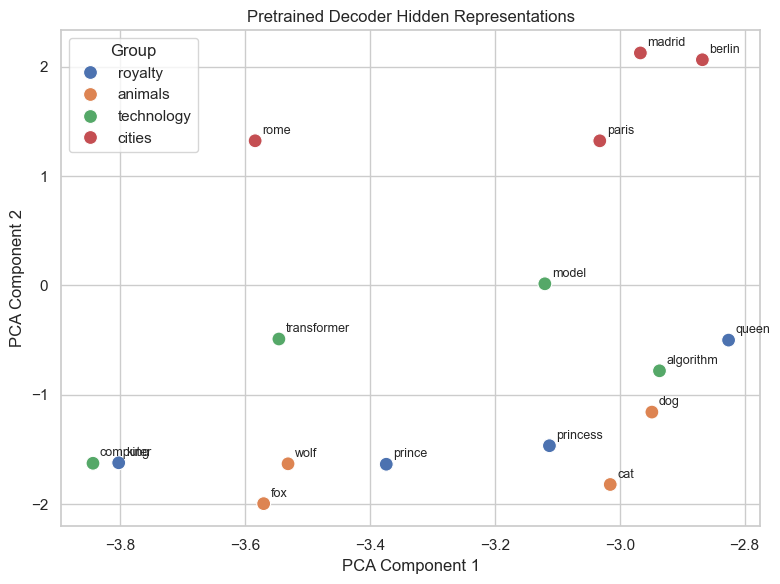

In [22]:
plot_pca(
    points=pretrained_points,
    groups=groups,
    names=names,
    title="Pretrained Decoder Hidden Representations",
    save_path="../assets/pretrained_hidden_pca.png"
)

## Layer-wise Representation Distance

In [25]:
def extract_all_layer_hidden_states(model, input_ids):
    captured = []
    hooks = []

    def make_hook():
        def hook_fn(module, inputs, output):
            captured.append(output.detach())
        return hook_fn

    for layer in model.layers:
        hooks.append(layer.register_forward_hook(make_hook()))

    model.eval()

    with torch.no_grad():
        _ = model(input_ids)

    for hook in hooks:
        hook.remove()

    return captured

In [26]:
def get_layerwise_sentence_vectors(model, sentences, tokenizer, device, max_length=128):
    all_sentence_layer_vectors = []

    for sentence in sentences:
        encoded = tokenizer(
            sentence,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding="max_length"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        hidden_states = extract_all_layer_hidden_states(model, input_ids)

        sentence_layer_vectors = []

        for hidden in hidden_states:
            mask = attention_mask.unsqueeze(-1)
            hidden = hidden * mask

            sentence_vector = hidden.sum(dim=1) / mask.sum(dim=1)
            sentence_layer_vectors.append(sentence_vector.squeeze(0).cpu())

        sentence_layer_vectors = torch.stack(sentence_layer_vectors)
        all_sentence_layer_vectors.append(sentence_layer_vectors)

    return torch.stack(all_sentence_layer_vectors)

In [27]:
random_layer_vectors = get_layerwise_sentence_vectors(
    model=random_model,
    sentences=sentences,
    tokenizer=tokenizer,
    device=device,
    max_length=pretrained_config.block_size
)

pretrained_layer_vectors = get_layerwise_sentence_vectors(
    model=pretrained_model,
    sentences=sentences,
    tokenizer=tokenizer,
    device=device,
    max_length=pretrained_config.block_size
)

print(random_layer_vectors.shape)
print(pretrained_layer_vectors.shape)

torch.Size([16, 4, 256])
torch.Size([16, 4, 256])


In [28]:
num_layers = random_layer_vectors.shape[1]

layer_distances = []

for layer_idx in range(num_layers):
    random_vecs = random_layer_vectors[:, layer_idx, :]
    pretrained_vecs = pretrained_layer_vectors[:, layer_idx, :]

    cosine_sim = F.cosine_similarity(
        random_vecs,
        pretrained_vecs,
        dim=-1
    )

    cosine_distance = 1 - cosine_sim
    mean_distance = cosine_distance.mean().item()

    layer_distances.append(mean_distance)

    print(f"Layer {layer_idx}: mean cosine distance = {mean_distance:.4f}");

Layer 0: mean cosine distance = 0.3472
Layer 1: mean cosine distance = 0.6962
Layer 2: mean cosine distance = 0.8833
Layer 3: mean cosine distance = 0.7918


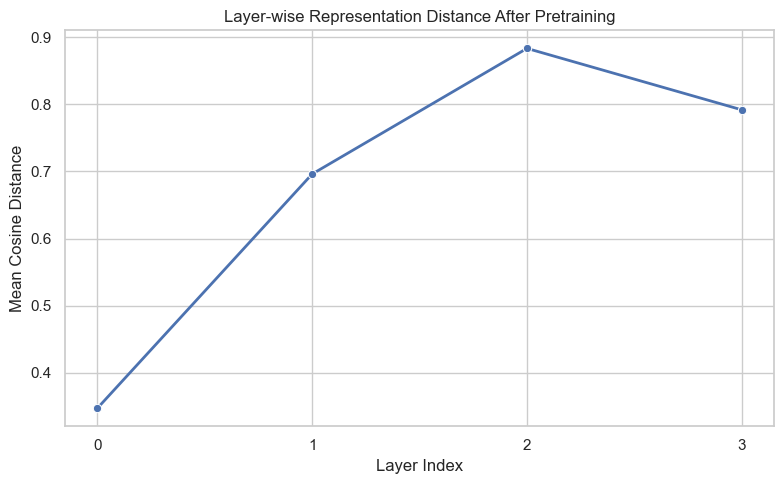

In [29]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    x=list(range(num_layers)),
    y=layer_distances,
    marker="o",
    linewidth=2
)

plt.title("Layer-wise Representation Distance After Pretraining")
plt.xlabel("Layer Index")
plt.ylabel("Mean Cosine Distance")
plt.xticks(list(range(num_layers)))
plt.tight_layout()
plt.savefig("../assets/layerwise_representation_distance.png", dpi=300)
plt.show()